# 03b · Fraud Analytics Chapter 3 — Descriptive Analytics for Fraud Detection
*Concept-by-concept, each with an explanation, a worked example and code.*
Descriptive (unsupervised) analytics needs **no fraud label**: it looks for unusual patterns, outliers and groups. It finds **unknown** patterns but flags "unusual", not "fraudulent" — so results are triage leads.

| # | Concept | # | Concept |
|---|---|---|---|
| 1 | Graphical outlier detection | 8 | Hierarchical clustering |
| 2 | OLAP: roll-up, drill-down, slice, dice, pivot tables | 9 | k-means (and k-medoids / k-modes) |
| 3 | Statistical outliers: z-score, Grubbs, Mahalanobis, distributions | 10 | Self-organizing maps |
| 4 | Break-point analysis | 11 | Clustering with constraints |
| 5 | Peer-group analysis | 12 | Evaluating and interpreting clustering solutions |
| 6 | Association rule analysis | 13 | One-class SVMs |
| 7 | Clustering: distance metrics | 14 | Comparison |

> The lab data has an **oracle** (true suspicious customers / confirmed card fraud). We use it only to *grade* methods — never as an input.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, itertools, warnings
warnings.filterwarnings("ignore")
from scipy import stats
from scipy.cluster import hierarchy as hc
from scipy.spatial.distance import pdist, squareform
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
import amlkit as ak

pd.set_option("display.float_format", "{:,.4f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid"); rng = np.random.default_rng(0)
txn = pd.read_pickle(ak.PROC / "txn_clean.pkl"); kyc = pd.read_pickle(ak.PROC / "kyc_clean.pkl"); feat = pd.read_pickle(ak.PROC / "features.pkl"); truth = ak.load_truth()
cards = ak.card_features(txn[txn.channel == "card_online"]); y = feat.is_launderer.values
CL = ["log_n_txn", "log_mean_amt", "log_credits", "log_amt_cash_deposit", "log_amt_wire_in", "cash_share_credits", "log_n_counterparties", "night_share", "hr_share",
      "log_max_cash_agg_5d", "log_turnover_ratio", "flowthrough_max", "near_ctr_cnt"]
Z = StandardScaler().fit_transform(feat[CL]); RESULTS = {}
def grade(name, score, labels=y):
    s = np.nan_to_num(np.asarray(score, float)); RESULTS[name] = dict(AUC=roc_auc_score(labels, s), **{"P@100": labels[np.argsort(-s)[:100]].mean()}); return RESULTS[name]
print(f"{len(feat):,} customers x {len(CL)} behavioural variables | {len(cards):,} card-online transactions")

3,500 customers x 13 behavioural variables | 84,463 card-online transactions


## 1 · Graphical outlier detection procedures
* 1-D: **histogram**, **box plot**. 2-D: **scatter plot**. 3-D: 3-D scatter with rotation. In the book's insurance example three claims stand out by *high amount, many cars, short time since previous claim*.
* Strength: intuitive, no assumptions. Weakness: informal, limited to a few dimensions, needs an analyst to look.

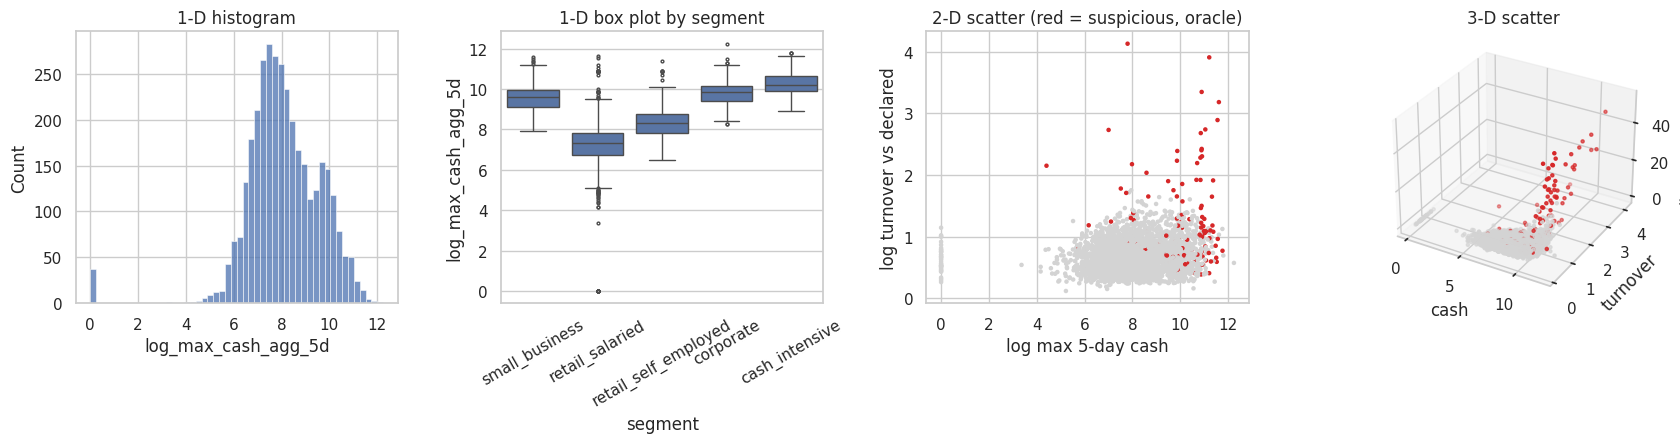

In [2]:
fig = plt.figure(figsize=(17, 4.6)); a1 = fig.add_subplot(1, 4, 1); a2 = fig.add_subplot(1, 4, 2); a3 = fig.add_subplot(1, 4, 3); a4 = fig.add_subplot(1, 4, 4, projection="3d")
sns.histplot(feat.log_max_cash_agg_5d, bins=50, ax=a1); a1.set_title("1-D histogram")
sns.boxplot(x=feat.segment, y=feat.log_max_cash_agg_5d, ax=a2, fliersize=2); a2.set_title("1-D box plot by segment"); a2.tick_params(axis="x", rotation=30)
a3.scatter(feat.log_max_cash_agg_5d, feat.log_turnover_ratio, s=5, c=np.where(y == 1, "tab:red", "lightgrey")); a3.set(title="2-D scatter (red = suspicious, oracle)", xlabel="log max 5-day cash", ylabel="log turnover vs declared")
a4.scatter(feat.log_max_cash_agg_5d, feat.log_turnover_ratio, feat.near_ctr_cnt, s=5, c=np.where(y == 1, "tab:red", "lightgrey")); a4.set(title="3-D scatter", xlabel="cash", ylabel="turnover", zlabel="#near-threshold")
plt.tight_layout(); plt.show()

## 2 · OLAP: roll-up, drill-down, slicing, dicing, pivot tables
A multidimensional **cube** (e.g. claim amount × number of cars × recency of previous claim) is explored with:
* **Roll-up** — aggregate across one or more dimensions · **Drill-down** — add a dimension for more detail
* **Slicing** — pick one value/range along one dimension · **Dicing** — fix values on *all* dimensions → sub-cube
* **Pivot tables** — cross-tabulate chosen dimensions (Fig 3.3: RFM averages for fraud vs non-fraud on non-EU transactions).

Here the cube is card-not-present transactions × **amount** × **recency** (time since previous txn) × **frequency** (txns in previous 24 h).

In [3]:
cube = cards.assign(amount_band=pd.cut(cards.amount_usd, [0, 50, 100, 250, 1000, np.inf], labels=["<50", "50-100", "100-250", "250-1000", ">1000"]),
                    recency=pd.cut(np.expm1(cards.log_hrs_since_prev), [-1, 1, 24, 168, np.inf], labels=["<1h", "1-24h", "1-7d", ">7d"]),
                    frequency=pd.cut(cards.n_prev_24h, [-1, 0, 1, 3, np.inf], labels=["0", "1", "2-3", "4+"]), region=np.where(cards.foreign == 1, "foreign", "domestic"))
meas = lambda d: pd.Series({"txns": len(d), "frauds": d.is_fraud.sum(), "fraud_rate": d.is_fraud.mean()})
print("ROLL-UP to (recency):");                          display(cube.groupby("recency", observed=True).apply(meas))
print("DRILL-DOWN adding (frequency):");                  display(cube.groupby(["recency", "frequency"], observed=True).apply(meas).query("txns > 200").sort_values("fraud_rate", ascending=False).head(6))
print("SLICE frequency == '4+':");                        display(cube[cube.frequency == "4+"].groupby("amount_band", observed=True).apply(meas))
dice = cube[(cube.amount_band.isin(["100-250", "250-1000"])) & (cube.recency.isin(["<1h", "1-24h"])) & (cube.frequency.isin(["2-3", "4+"]))]
print("DICE (amount 100-1000, recency < 24h, frequency >= 2):", len(dice), "txns, fraud rate", round(dice.is_fraud.mean(), 3), "vs population", round(cards.is_fraud.mean(), 4))

ROLL-UP to (recency):


,txns,frauds,fraud_rate
recency,,,
<1h,677.0000,215.0000,0.3176
1-24h,"8,411.0000",63.0000,0.0075
1-7d,"31,391.0000",32.0000,0.0010
>7d,"43,984.0000",73.0000,0.0017


DRILL-DOWN adding (frequency):


txns  frauds  fraud_rate
recency frequency                                
<1h     1            431.0000 41.0000      0.0951
1-24h   2-3          702.0000 16.0000      0.0228
        1          7,705.0000 47.0000      0.0061
>7d     0         43,984.0000 73.0000      0.0017
1-7d    0         31,391.0000 32.0000      0.0010

SLICE frequency == '4+':


,txns,frauds,fraud_rate
amount_band,,,
<50,7.0000,6.0000,0.8571
50-100,31.0000,30.0000,0.9677
100-250,33.0000,30.0000,0.9091
250-1000,22.0000,22.0000,1.0000
>1000,2.0000,2.0000,1.0000


DICE (amount 100-1000, recency < 24h, frequency >= 2): 487 txns, fraud rate 0.242 vs population 0.0045


In [4]:
# Fig 3.3 analogue: pivot table, filtered to foreign transactions, RFM averages for fraud vs non-fraud
f = cube[cube.region == "foreign"]
pt = f.pivot_table(index="is_fraud", values=["amount_usd", "n_prev_24h", "log_hrs_since_prev"], aggfunc=["count", "mean"]).round(3)
pt.columns = [f"{a}({b})" for a, b in pt.columns]; display(pt)
display(cube.pivot_table(index="amount_band", columns="frequency", values="is_fraud", aggfunc="mean", observed=True, margins=True).round(4))

,count(amount_usd),count(log_hrs_since_prev),count(n_prev_24h),mean(amount_usd),mean(log_hrs_since_prev),mean(n_prev_24h)
is_fraud,,,,,,
0,16815,16815,16815,130.5720,5.0480,0.1170
1,266,266,266,210.5300,1.8410,2.1130


frequency,0,1,2-3,4+,All
amount_band,,,,,
<50,0.0005,0.0047,0.0694,0.8571,0.0015
50-100,0.0011,0.0087,0.0859,0.9677,0.0039
100-250,0.0026,0.0145,0.1522,0.9091,0.0070
250-1000,0.0023,0.0190,0.1538,1.0000,0.0088
>1000,0.0000,0.0000,0.2000,1.0000,0.0073
All,0.0014,0.0108,0.1168,0.9474,0.0045


## 3 · Statistical outlier detection
* **z-score** |z| > 3 (assumes normality). 
* **Grubbs test** — H₀: no outliers. Take G = max |z|; outlier at level α if **G > (N−1)/√N · √( t² / (N−2+t²) )** with t = t_{α/(2N), N−2}; remove it and repeat.
* **Mahalanobis distance** √((x−x̄)ᵀ S⁻¹ (x−x̄)) for multivariate outliers (z-score generalisation).
* Weakness of all three: they assume an underlying **normal** distribution. Alternative: **fit a distribution or mixture** (maximum likelihood / EM) and flag observations with a very low density.

In [5]:
def grubbs(v, alpha=0.05):
    v = np.asarray(v, float).copy(); out = []
    while len(v) > 3:
        N = len(v); zs = np.abs((v - v.mean()) / v.std(ddof=1)); i = zs.argmax(); t = stats.t.ppf(1 - alpha / (2 * N), N - 2)
        if zs[i] > (N - 1) / np.sqrt(N) * np.sqrt(t ** 2 / (N - 2 + t ** 2)): out.append(v[i]); v = np.delete(v, i)
        else: break
    return out
print("Grubbs on a normal sample + 2 planted outliers:", np.round(grubbs(np.r_[rng.normal(100, 10, 200), [180, 20]]), 1))

v3 = feat[["log_max_cash_agg_5d", "log_turnover_ratio", "log_credits"]].values
zmax = np.abs(stats.zscore(v3)).max(1)                                                               # univariate z, worst dimension
mu, S = v3.mean(0), np.cov(v3.T); d2 = np.einsum("ij,jk,ik->i", v3 - mu, np.linalg.inv(S), v3 - mu)   # squared Mahalanobis
gmm = GaussianMixture(3, random_state=0).fit(v3); nll = -gmm.score_samples(v3)                       # mixture density: low density = outlier
print("flagged: |z|>3 ->", int((zmax > 3).sum()), "| Mahalanobis chi2(3) 99.9% ->", int((d2 > stats.chi2.ppf(.999, 3)).sum()), "| lowest 1% mixture density ->", int((nll > np.quantile(nll, .99)).sum()))
for n_, s_ in [("z-score (max over 3 vars)", zmax), ("Mahalanobis distance", np.sqrt(d2)), ("Gaussian-mixture density", nll)]: print(f"{n_:28s}", {k: round(v, 3) for k, v in grade(n_, s_).items()})

Grubbs on a normal sample + 2 planted outliers: [ 20. 180.]
flagged: |z|>3 -> 85 | Mahalanobis chi2(3) 99.9% -> 61 | lowest 1% mixture density -> 35
z-score (max over 3 vars)    {'AUC': 0.83, 'P@100': np.float64(0.32)}
Mahalanobis distance         {'AUC': 0.818, 'P@100': np.float64(0.31)}
Gaussian-mixture density     {'AUC': 0.848, 'P@100': np.float64(0.29)}


## 4 · Break-point analysis *(intra-account, Bolton & Hand)*
A **break point** = sudden change in an account's behaviour. Take a fixed window of transactions (book: **24 = 20 old + 4 new**). The old part is the **local model/profile**; compare the new part with it using a **Student's t-test** on the means and rank windows by the t statistic.

27,383 windows, 118 contain a fraud in the new part | AUC of t on AMOUNT = 0.539 | AUC of t on INTER-ARRIVAL TIME = 0.768
Break-point analysis is only as good as the variable it monitors: fraud amounts overlap normal spending, but bursts collapse the gap between transactions.
precision in the 200 highest-t windows (inter-arrival): 11.5%  vs base rate 0.43%


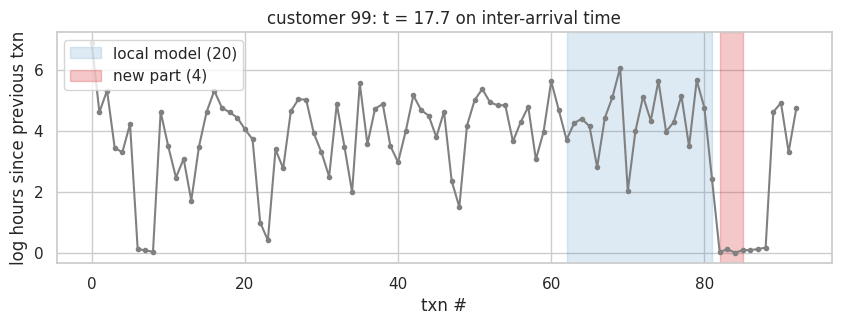

In [6]:
rows = []
for cid, g in cards.groupby("customer_id"):
    a, fr = g.log_amt.values, g.is_fraud.values
    if len(a) < 24: continue
    W, Wf = sliding_window_view(a, 24), sliding_window_view(fr, 24)
    old, new = W[:, :20], W[:, 20:]
    t = (new.mean(1) - old.mean(1)) / np.sqrt(old.var(1, ddof=1) / 20 + new.var(1, ddof=1) / 4 + 1e-9)          # Welch t: new vs local model
    h = g.log_hrs_since_prev.values; Wh = sliding_window_view(h, 24); oh_, nh_ = Wh[:, :20], Wh[:, 20:]
    t_gap = (oh_.mean(1) - nh_.mean(1)) / np.sqrt(oh_.var(1, ddof=1) / 20 + nh_.var(1, ddof=1) / 4 + 1e-9)          # same test on the inter-arrival time (bursts = shrinking gaps)
    rows.append(pd.DataFrame({"customer_id": cid, "end": np.arange(23, len(a)), "t": t, "t_gap": t_gap, "fraud_in_new": Wf[:, 20:].max(1)}))
bp = pd.concat(rows, ignore_index=True)
print(f"{len(bp):,} windows, {int(bp.fraud_in_new.sum())} contain a fraud in the new part | AUC of t on AMOUNT = {roc_auc_score(bp.fraud_in_new, bp.t):.3f} | AUC of t on INTER-ARRIVAL TIME = {roc_auc_score(bp.fraud_in_new, bp.t_gap):.3f}")
print("Break-point analysis is only as good as the variable it monitors: fraud amounts overlap normal spending, but bursts collapse the gap between transactions.")
top = bp.nlargest(200, "t_gap"); print(f"precision in the 200 highest-t windows (inter-arrival): {top.fraud_in_new.mean():.1%}  vs base rate {bp.fraud_in_new.mean():.2%}")
ex = bp[(bp.fraud_in_new == 1)].nlargest(1, "t_gap").iloc[0]; g = cards[cards.customer_id == ex.customer_id].reset_index(drop=True); e = int(ex.end)
fig, ax = plt.subplots(figsize=(10, 3)); ax.plot(g.log_hrs_since_prev.iloc[:e + 8], "o-", ms=3, c="grey"); ax.axvspan(e - 23, e - 4, alpha=.15, color="tab:blue", label="local model (20)"); ax.axvspan(e - 3, e, alpha=.25, color="tab:red", label="new part (4)")
ax.set(title=f"customer {int(ex.customer_id)}: t = {ex.t_gap:.1f} on inter-arrival time", xlabel="txn #", ylabel="log hours since previous txn"); ax.legend(); plt.show()

## 5 · Peer-group analysis *(inter-account)*
Step 1: find the account's **peers** (business knowledge — same job/region — or statistical similarity, e.g. Euclidean). Number of peers: not too small (noise) or too large (blind to local irregularities). Step 2: contrast the target with its peers: **t = (y_n − x̄_{1:k,n}) / s**; rank by t. Advantage over break-point: **inter-account** comparison is immune to changes that hit *everyone* (Christmas), while both detect **local** anomalies.

We use weekly cash-deposit totals; peers are found on the *early* weeks and the target is tested on the *last* weeks.

In [7]:
cd = txn[txn.channel == "cash_deposit"].assign(week=lambda d: np.minimum(d.day // 7, 51))
Wk = np.log1p(cd.pivot_table(index="customer_id", columns="week", values="amount_usd", aggfunc="sum", fill_value=0).reindex(feat.customer_id, fill_value=0).reindex(columns=range(52), fill_value=0).values)
elig = (feat.n_cash_dep >= 50).values; X = Wk[elig]; ye = y[elig]; typ = feat.typology.values[elig]

def break_point_t(X, L=4, old=20):
    n_, o_ = X[:, -L:], X[:, -(L + old):-L]; return (n_.mean(1) - o_.mean(1)) / np.sqrt(o_.var(1, ddof=1) / old + n_.var(1, ddof=1) / L + 1e-9)
def peer_group_t(X, L=4, k=20):
    hist, recent = X[:, :-L], X[:, -L:].mean(1); idx = NearestNeighbors(n_neighbors=k + 1).fit(hist).kneighbors(hist)[1][:, 1:]     # peers by Euclid on history
    return (recent - recent[idx].mean(1)) / (recent[idx].std(1, ddof=1) + 1e-9)
t_bp, t_pg = break_point_t(X), peer_group_t(X)
m = np.isin(typ, ["commingling", "none"]); is_c = typ == "commingling"
print(f"eligible customers {len(X)} | AUC for 'commingling' vs normal  break-point {roc_auc_score(is_c[m], t_bp[m]):.3f} | peer-group {roc_auc_score(is_c[m], t_pg[m]):.3f}")
# 'Christmas' effect: everyone deposits more in the last 4 weeks
Xs = X.copy(); Xs[:, -4:] = np.log1p(np.expm1(Xs[:, -4:]) * 2.5)
print(pd.DataFrame({"break-point": [np.mean(np.abs(t_bp) > 3), np.mean(np.abs(break_point_t(Xs)) > 3)], "peer-group": [np.mean(np.abs(t_pg) > 3), np.mean(np.abs(peer_group_t(Xs)) > 3)]},
                   index=["share flagged (|t|>3) normal times", "share flagged with seasonal spike"]))
print("Reading: the break-point test only sees change INSIDE its last 24-week window, so a level shift that happened earlier (commingling) is invisible to it; peers, chosen on early weeks, still expose the persistent deviation.  (Notebook 03 scans every split point and does find those breaks.)")
grade("Break-point (max t, cash weeks)", np.where(elig, 0, 0) + pd.Series(np.abs(t_bp), index=np.flatnonzero(elig)).reindex(range(len(feat)), fill_value=0).values)
grade("Peer-group t (cash weeks)", pd.Series(t_pg, index=np.flatnonzero(elig)).reindex(range(len(feat)), fill_value=0).values)

eligible customers 572 | AUC for 'commingling' vs normal  break-point 0.533 | peer-group 0.736
                                    break-point  peer-group
share flagged (|t|>3) normal times       0.0472      0.0559
share flagged with seasonal spike        0.2150      0.0664
Reading: the break-point test only sees change INSIDE its last 24-week window, so a level shift that happened earlier (commingling) is invisible to it; peers, chosen on early weeks, still expose the persistent deviation.  (Notebook 03 scans every split point and does find those breaks.)


{'AUC': 0.4806052902104384, 'P@100': np.float64(0.18)}

## 6 · Association rule analysis
Find frequently co-occurring items (originally *market basket*; in fraud: **parties involved in a claim** — insured, police officer, adjuster, repair shop — to spot rings). Two steps:
1. **Frequent item sets**: **support(X) = #transactions containing X / #transactions** ≥ minimum support.
2. **Rules X ⇒ Y**: **confidence = support(X ∪ Y) / support(X) = P(Y|X)** ≥ minimum confidence (and **lift** = confidence / support(Y): > 1 = positive association). Rules are *stochastic* and *correlational*, not causal — a ring signal worth *inspecting*, not proof.

In [8]:
def apriori(onehot, min_support, max_len=3):
    cols = list(onehot.columns); A = onehot.values.astype(bool); n_ = len(A); idx = {c: i for i, c in enumerate(cols)}
    sup = {frozenset([c]): A[:, i].mean() for c, i in idx.items()}; freq = {k: v for k, v in sup.items() if v >= min_support}; cur = list(freq)
    for k in range(2, max_len + 1):
        cand = {a | b for a in cur for b in cur if len(a | b) == k}; nxt = []
        for c in cand:
            if all(frozenset(s) in freq for s in itertools.combinations(c, k - 1)):
                s_ = A[:, [idx[i] for i in c]].all(1).mean()
                if s_ >= min_support: freq[c] = s_; nxt.append(c)
        cur = nxt
    return freq
def rules_from(freq, min_conf):
    out = []
    for I, s in freq.items():
        if len(I) < 2: continue
        for r in range(1, len(I)):
            for ant in itertools.combinations(I, r):
                ant = frozenset(ant); cons = I - ant; conf = s / freq[ant]
                if conf >= min_conf: out.append(dict(antecedent=set(ant), consequent=set(cons), support=s, confidence=conf, lift=conf / freq[cons]))
    return pd.DataFrame(out).sort_values(["lift", "confidence"], ascending=False)

# Book Table 3.2: insurance claims and the parties involved
claims = [{"insured A", "police X", "adjuster 1", "shop 1"}, {"insured A", "adjuster 2", "police X"}, {"insured A", "police Y", "shop 1"}, {"insured A", "adjuster 1", "police Y"},
          {"insured B", "adjuster 2", "shop 2", "police Z"}, {"insured A", "shop 2", "shop 1", "police X"}, {"insured C", "police X", "shop 1"}, {"insured A", "shop 1", "police Z"},
          {"insured A", "shop 1", "police X", "adjuster 1"}, {"insured B", "adjuster 3", "shop 1"}]
oh = pd.DataFrame([{i: True for i in c} for c in claims]).fillna(False).astype(bool)
freq = apriori(oh, 0.10, 3)
print("support{insured A, police X, shop 1} =", freq[frozenset(["insured A", "police X", "shop 1"])], "(book: 30%)")
r_ = rules_from(freq, 0.5); rr = r_[(r_.antecedent == {"insured A", "police X"}) & (r_.consequent == {"shop 1"})]; print("confidence(A & X => shop 1) =", float(rr.confidence.iloc[0]), "(book: 75%)")
assert abs(freq[frozenset(["insured A", "police X", "shop 1"])] - 0.3) < 1e-9 and abs(float(rr.confidence.iloc[0]) - 0.75) < 1e-9
r_.head(5)

support{insured A, police X, shop 1} = 0.3 (book: 30%)
confidence(A & X => shop 1) = 0.7499999999999999 (book: 75%)


,antecedent,consequent,support,confidence,lift
66,{adjuster 3},"{insured B, shop 1}",0.1000,1.0000,10.0000
67,"{insured B, shop 1}",{adjuster 3},0.1000,1.0000,10.0000
20,{adjuster 3},{insured B},0.1000,1.0000,5.0000
43,"{insured B, police Z}",{adjuster 2},0.1000,1.0000,5.0000
44,"{insured B, adjuster 2}",{police Z},0.1000,1.0000,5.0000


In [9]:
# Lab: 'parties involved' in outgoing wires to high-risk jurisdictions = customer segment, destination, size band and (recurrent) counterparty
w = txn[(txn.channel == "wire_out") & (txn.country.isin(ak.HIGH_RISK))].merge(kyc[["customer_id", "segment"]], on="customer_id")
w["band"] = pd.cut(w.amount_usd, [0, 5e3, 2e4, 5e4, np.inf], labels=["<5k", "5-20k", "20-50k", ">50k"]).astype(str)
cpc = w.counterparty_id.value_counts(); w["cp"] = np.where(w.counterparty_id.map(cpc) >= 12, "cp_" + w.counterparty_id.astype(str), "cp_other")
ohw = pd.get_dummies(w[["segment", "country", "band", "cp"]].astype(str), prefix="", prefix_sep="").drop(columns="cp_other", errors="ignore")
fq = apriori(ohw, 0.002, 3); rl = rules_from(fq, 0.3)
print(f"{len(w):,} wire events to high-risk countries | {len(fq)} frequent item sets | {len(rl)} rules")
shell = txn[(txn.counterparty_id >= len(kyc) + 5000)].counterparty_id.unique()
rl = rl.assign(shell=rl.antecedent.map(lambda a: any(i.startswith("cp_") and int(i[3:]) in shell for i in a)))
rl[rl.antecedent.map(lambda a: any(i.startswith("cp_") for i in a))].head(8)

5,919 wire events to high-risk countries | 177 frequent item sets | 158 rules


,antecedent,consequent,support,confidence,lift,shell
1,{cp_8504},{20-50k},0.0030,0.9000,6.4415,True
32,{cp_8503},{20-50k},0.0032,0.7600,5.4395,True
19,{cp_8505},{20-50k},0.0024,0.6667,4.7715,True
23,{cp_8501},{20-50k},0.0020,0.6667,4.7715,True
0,{cp_6690},{corporate},0.0022,1.0000,1.6936,False
3,{cp_5988},{corporate},0.0022,1.0000,1.6936,False
13,{cp_8301},{corporate},0.0025,1.0000,1.6936,False
16,{cp_4792},{corporate},0.0022,1.0000,1.6936,False


## 7 · Clustering: introduction and distance metrics
**Aim:** segments that are internally *cohesive* and mutually *separated*. In fraud: cluster transactions/claims/tax statements/cash transfers; **anomalies sit in small, sparse clusters**. Clustering data: customer, account, transaction characteristics; **RFM** is the classic transaction set. Avoid redundant correlated inputs.

**Distance metrics**
* Continuous: **Minkowski L_p** = (Σ|x_ik − x_jk|^p)^(1/p): p=1 **Manhattan**, p=2 **Euclidean**. Variables on large scales dominate → **standardize** first. Also correlation- and cosine-based distances.
* Binary red flags: **simple matching coefficient (SMC)** (all matches) vs **Jaccard** (ignores 0-0 matches — better when few flags are raised).
* Categorical: dummies, SMC/mismatch counts, **Gower** for mixed types.

In [10]:
a, b = np.array([1500, 10]), np.array([1000, 5])                                         # book example: (monetary, recency)
print("Euclidean =", round(np.linalg.norm(a - b), 2), "| Manhattan =", np.abs(a - b).sum(), "(book: 500 and 505)  -> 'monetary' dominates because of its scale")
Xs2 = StandardScaler().fit(np.array([[1500, 10], [1000, 5], [200, 1], [3000, 30]])).transform(np.array([a, b])); print("after standardization Euclidean =", round(np.linalg.norm(Xs2[0] - Xs2[1]), 2))
u, v = np.array([1, 2, 3, 4]), np.array([2, 4, 6, 8]); print("Minkowski p=1,2,3:", [round(float((np.abs(u - v) ** p).sum() ** (1 / p)), 2) for p in (1, 2, 3)], "| cosine distance:", round(1 - u @ v / (np.linalg.norm(u) * np.linalg.norm(v)), 3), "| correlation distance:", round(1 - np.corrcoef(u, v)[0, 1], 3))

# Binary red flags (book): claim 1 = Y N Y Y N, claim 2 = Y Y N N N
c1, c2 = np.array([1, 0, 1, 1, 0]), np.array([1, 1, 0, 0, 0])
smc = (c1 == c2).mean(); jac = ((c1 & c2).sum()) / ((c1 | c2).sum()); print(f"SMC = {smc:.2f} (2/5) | Jaccard = {jac:.2f} (1/4)"); assert abs(smc - 0.4) < 1e-9 and abs(jac - 0.25) < 1e-9

Euclidean = 500.02 | Manhattan = 505 (book: 500 and 505)  -> 'monetary' dominates because of its scale
after standardization Euclidean = 0.66
Minkowski p=1,2,3: [10.0, 5.48, 4.64] | cosine distance: 0.0 | correlation distance: 0.0
SMC = 0.40 (2/5) | Jaccard = 0.25 (1/4)


In [11]:
# Why Jaccard: 20 red flags, few raised -> SMC says everybody is similar (0-0 matches dominate)
flags = pd.DataFrame({"near_ctr": feat.near_ctr_cnt >= 3, "cash_burst": feat.max_cash_agg_5d >= 10_000, "turnover3x": feat.turnover_ratio > 3, "flowthru": feat.flowthrough_max >= .9,
                      "hr_cty": feat.hr_share > .05, "pep": feat.is_pep == 1, "night": feat.night_share > .1, "many_cp": feat.n_counterparties > 60}).astype(int).values
sub = flags[rng.choice(len(flags), 400, replace=False)]
smc_m = 1 - squareform(pdist(sub, "hamming")); jac_m = 1 - squareform(pdist(sub.astype(bool), "jaccard"))
iu = np.triu_indices(400, 1); print(f"mean pairwise similarity: SMC {smc_m[iu].mean():.2f} vs Jaccard {np.nanmean(jac_m[iu]):.2f}  (many customers raise no flag at all -> Jaccard undefined 0/0 for those pairs)")
def gower(df):
    n_ = len(df); D = np.zeros((n_, n_)); cols = df.columns
    for c_ in cols:
        s = df[c_]
        if pd.api.types.is_numeric_dtype(s): x = s.values.astype(float); D += np.abs(x[:, None] - x[None, :]) / (np.ptp(x) + 1e-12)      # range-normalised absolute difference
        else: x = np.asarray(s.astype(str).to_numpy(), dtype=object); D += (x[:, None] != x[None, :]).astype(float)                                                                      # mismatch for categories
    return D / len(cols)
mixed = feat[["segment", "region", "country_risk", "log_credits", "cash_share_credits", "hr_share"]].iloc[:300]
Dg = gower(mixed); print("Gower distance for mixed data (300 customers): range", Dg.min().round(2), "-", Dg.max().round(2), "| mean", Dg.mean().round(3))

mean pairwise similarity: SMC 0.85 vs Jaccard 0.41  (many customers raise no flag at all -> Jaccard undefined 0/0 for those pairs)
Gower distance for mixed data (300 customers): range 0.0 - 0.8 | mean 0.345


## 8 · Hierarchical clustering
* **Agglomerative** (bottom-up: start with one cluster per observation and merge the closest pair) vs **divisive** (top-down splitting). Output = **dendrogram**; cut at a height to obtain clusters.
* **Linkage** defines the distance between clusters: **single** (nearest members → *chaining*, long thin clusters), **complete** (farthest members → tight, balanced, spherical), **average**, **centroid**, **Ward** (minimise variance increase → balanced clusters).

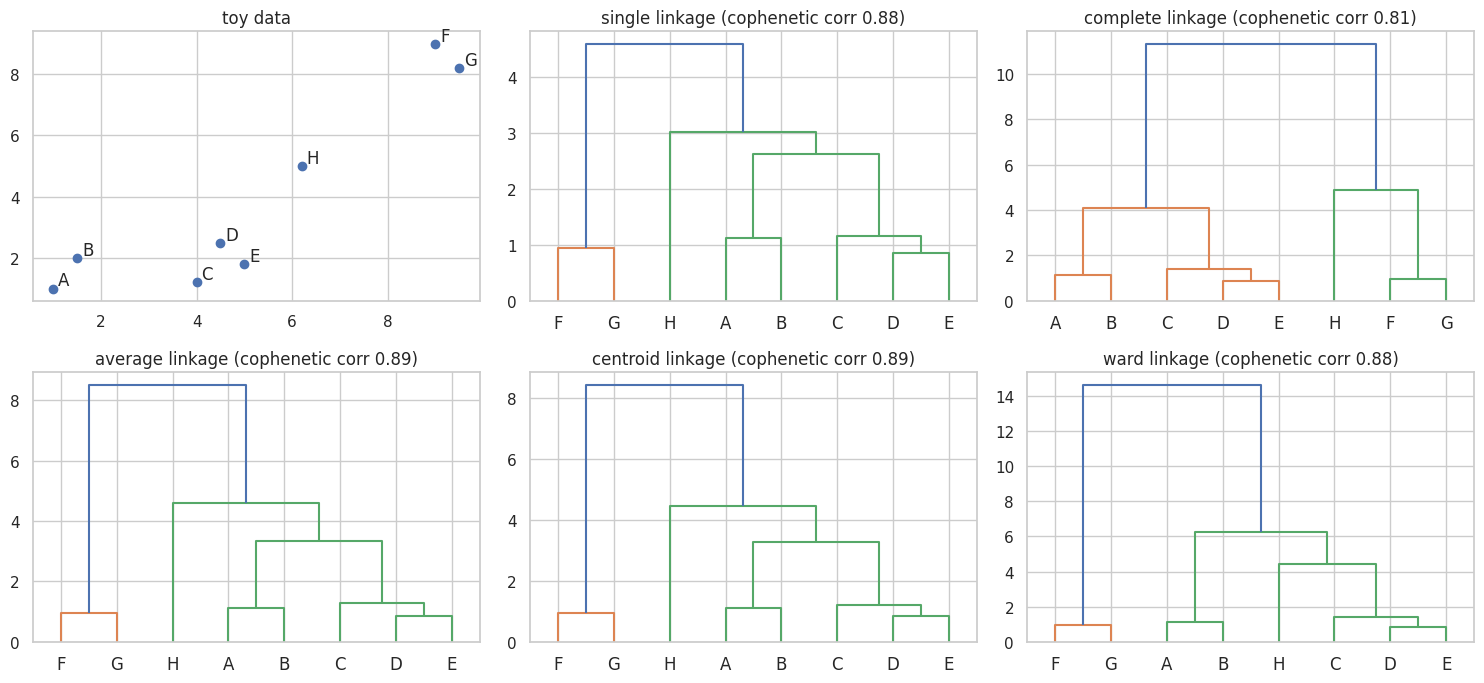

{'single': [2, 2, 2, 2, 2, 1, 1, 3], 'complete': [1, 1, 1, 1, 1, 2, 2, 3], 'ward': [2, 2, 3, 3, 3, 1, 1, 3]}


In [12]:
pts = pd.DataFrame({"x": [1, 1.5, 4, 4.5, 5, 9, 9.5, 6.2], "y": [1, 2, 1.2, 2.5, 1.8, 9, 8.2, 5.0]}, index=list("ABCDEFGH"))
fig, ax = plt.subplots(2, 3, figsize=(15, 7)); ax = ax.ravel(); ax[0].scatter(pts.x, pts.y)
for n_, r in pts.iterrows(): ax[0].annotate(n_, (r.x + .1, r.y + .1))
ax[0].set_title("toy data")
for a_, meth in zip(ax[1:], ["single", "complete", "average", "centroid", "ward"]):
    Zl = hc.linkage(pts.values, meth); hc.dendrogram(Zl, labels=pts.index.tolist(), ax=a_); coph = hc.cophenet(Zl, pdist(pts.values))[0]
    a_.set_title(f"{meth} linkage (cophenetic corr {coph:.2f})")
plt.tight_layout(); plt.show()
print({m_: hc.fcluster(hc.linkage(pts.values, m_), 3, "maxclust").tolist() for m_ in ["single", "complete", "ward"]})

In [13]:
# chaining effect on lab data: single vs complete vs ward linkage on 500 customers (cluster-size balance)
samp = rng.choice(len(Z), 500, replace=False)
for meth in ["single", "complete", "average", "ward"]:
    lab = hc.fcluster(hc.linkage(Z[samp], meth), 6, "maxclust"); sz = np.sort(np.bincount(lab)[1:])[::-1]; print(f"{meth:9s} cluster sizes: {sz.tolist()}")

# divisive (top-down) clustering: recursively bisect the largest cluster with 2-means
def divisive(X, k):
    groups = [np.arange(len(X))]
    while len(groups) < k:
        g = groups.pop(int(np.argmax([len(q) for q in groups]))); lab = KMeans(2, n_init=5, random_state=0).fit_predict(X[g]); groups += [g[lab == 0], g[lab == 1]]
    return groups
print("divisive sizes:", sorted([len(g) for g in divisive(Z[samp], 6)], reverse=True))

single    cluster sizes: [494, 2, 1, 1, 1, 1]
complete  cluster sizes: [361, 115, 11, 7, 3, 3]
average   cluster sizes: [479, 8, 6, 3, 2, 2]
ward      cluster sizes: [249, 115, 97, 22, 9, 8]
divisive sizes: [159, 135, 95, 75, 31, 5]


## 9 · k-means (+ k-medoids, k-modes)
1. choose *k* seeds → 2. assign each observation to the nearest centroid → 3. recompute centroids → 4. repeat until stable. **k must be given** (expert, hierarchical result, or try several *k* and compare); try **different seeds** to check stability. The mean is **outlier-sensitive** (a problem in fraud) → **k-medoid** (median-like) for robustness; **k-mode** for categorical data.

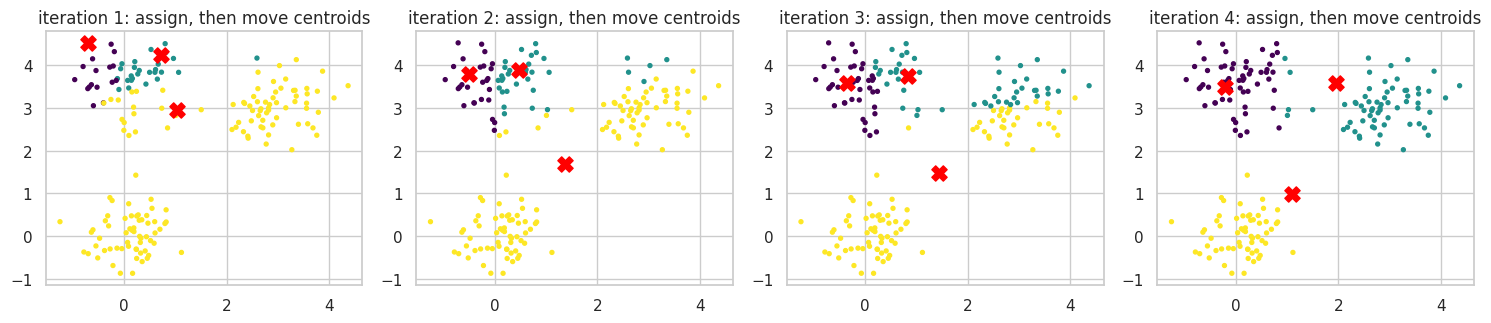

from-scratch SSE = 90.0 | sklearn inertia = 90.0


In [14]:
def kmeans_steps(X, k, seed=0, iters=6):
    r = np.random.default_rng(seed); C = X[r.choice(len(X), k, replace=False)]; hist = []
    for _ in range(iters):
        lab = np.argmin(((X[:, None] - C[None]) ** 2).sum(-1), 1); hist.append((C.copy(), lab.copy()))
        newC = np.array([X[lab == j].mean(0) if (lab == j).any() else C[j] for j in range(k)])
        if np.allclose(newC, C): break
        C = newC
    return hist
blobs = np.r_[rng.normal([0, 0], .5, (60, 2)), rng.normal([3, 3], .5, (60, 2)), rng.normal([0, 3.5], .5, (60, 2))]
hist = kmeans_steps(blobs, 3, seed=4); fig, ax = plt.subplots(1, min(4, len(hist)), figsize=(15, 3.4), squeeze=False)
for i, a_ in enumerate(ax[0]): C, lab = hist[i]; a_.scatter(*blobs.T, c=lab, s=8, cmap="viridis"); a_.scatter(*C.T, c="red", marker="X", s=120); a_.set_title(f"iteration {i + 1}: assign, then move centroids")
plt.tight_layout(); plt.show()
C_final, lab_final = hist[-1]; sse = sum(((blobs[lab_final == j] - C_final[j]) ** 2).sum() for j in range(3)); print(f"from-scratch SSE = {sse:.1f} | sklearn inertia = {KMeans(3, n_init=10, random_state=0).fit(blobs).inertia_:.1f}")

In [15]:
# stability across seeds & choice of k on the customer data
labs = [KMeans(5, n_init=1, random_state=s).fit_predict(Z) for s in range(8)]
print("mean pairwise ARI between 8 single-start runs (1 = perfectly stable):", round(np.mean([adjusted_rand_score(labs[i], labs[j]) for i in range(8) for j in range(i + 1, 8)]), 3))
print(pd.DataFrame({k: dict(SSE=KMeans(k, n_init=10, random_state=0).fit(Z).inertia_, silhouette=silhouette_score(Z, KMeans(k, n_init=10, random_state=0).fit_predict(Z), sample_size=2000, random_state=0)) for k in range(2, 9)}).T)

def kmedoids(X, k, iters=30, seed=0):
    r = np.random.default_rng(seed); D = squareform(pdist(X, "cityblock")); med = r.choice(len(X), k, replace=False)
    for _ in range(iters):
        lab = D[:, med].argmin(1); new = np.array([np.flatnonzero(lab == j)[D[np.ix_(lab == j, lab == j)].sum(1).argmin()] for j in range(k)])
        if set(new) == set(med): break
        med = new
    return med, D[:, med].argmin(1)
def kmodes(X, k, iters=20, seed=0):
    r = np.random.default_rng(seed); modes = X[r.choice(len(X), k, replace=False)].copy()
    for _ in range(iters):
        lab = (X[:, None, :] != modes[None]).sum(-1).argmin(1); new = np.array([[pd.Series(X[lab == j][:, c]).mode()[0] for c in range(X.shape[1])] if (lab == j).any() else modes[j] for j in range(k)])
        if (new == modes).all(): break
        modes = new
    return modes, lab
blob2 = np.r_[blobs, [[30, 30]]]                                                       # one extreme outlier
print("centroid of cluster 1 with/without outlier (k-means):", KMeans(3, n_init=10, random_state=0).fit(blob2).cluster_centers_[:, 0].round(2).tolist(), "vs", KMeans(3, n_init=10, random_state=0).fit(blobs).cluster_centers_[:, 0].round(2).tolist())
med, lm = kmedoids(blob2, 3); print("k-medoids medoids stay on real points:", blob2[med].round(2).tolist())
cat = feat[["segment", "region", "country_risk"]].values[:800]; modes, lk = kmodes(cat, 4); print("k-modes cluster modes:", modes.tolist())

mean pairwise ARI between 8 single-start runs (1 = perfectly stable): 0.552


          SSE  silhouette
2 26,931.0937      0.4474
3 23,957.8839      0.4433
4 21,154.2705      0.2048
5 18,792.2316      0.2192
6 17,358.6518      0.2079
7 16,095.0774      0.2146
8 14,847.7140      0.2181
centroid of cluster 1 with/without outlier (k-means): [1.52, 30.0, 0.12] vs [2.94, 0.12, 0.1]
k-medoids medoids stay on real points: [[3.57, 3.33], [2.65, 2.93], [0.09, 2.35]]
k-modes cluster modes: [['retail_self_employed', 'Sihanoukville', 'low'], ['retail_salaried', 'Phnom Penh', 'low'], ['retail_salaried', 'Phnom Penh', 'low'], ['retail_salaried', 'Phnom Penh', 'low']]


## 10 · Self-organizing maps (SOM)
A two-layer network (inputs → 2-D grid of neurons, rectangular/hexagonal) trained **unsupervised**. For input **x**: find the **best matching unit (BMU)** — the neuron whose weight vector w has the smallest Euclidean distance (standardize first!) — then update the BMU and its grid neighbours:

**w_i(t+1) = w_i(t) + h_ci(t) · [x(t) − w_i(t)]**, with **h_ci(t) = α(t) · exp(−‖r_c − r_i‖² / (2σ²(t)))**, decreasing learning rate α and radius σ. Visualise with the **U-matrix** (average distance between a neuron and its neighbours; dark = cluster boundary) and **component planes** (one variable's weights across the map). No objective function → harder to compare SOMs; the number of clusters is **not** forced equal to the number of neurons.

quantization error (mean distance to BMU): 1.182


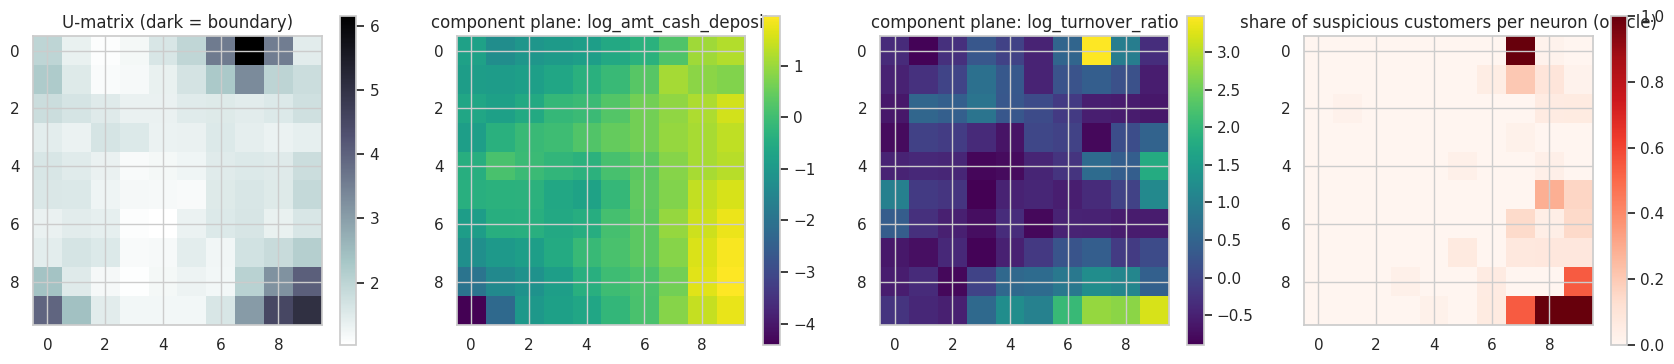

SOM + k-means on the codebook: suspicious rate per cluster {0: 0.002, 1: 0.098, 2: 0.065, 3: 0.007, 4: 0.803}


{'AUC': 0.8740138334163915, 'P@100': np.float64(0.57)}

In [16]:
class SOM:
    def __init__(self, rows, cols, dim, seed=0):
        self.rows, self.cols = rows, cols; r = np.random.default_rng(seed); self.W = r.normal(0, .1, (rows * cols, dim)); self.pos = np.array([(i, j) for i in range(rows) for j in range(cols)], float)
    def bmu(self, x): return ((self.W - x) ** 2).sum(1).argmin()
    def fit(self, X, epochs=15, a0=0.5, s0=None, seed=0):
        r = np.random.default_rng(seed); s0 = s0 or max(self.rows, self.cols) / 2; T = epochs * len(X); t = 0
        for _ in range(epochs):
            for i in r.permutation(len(X)):
                a, s = a0 * np.exp(-t / T * 3), s0 * np.exp(-t / T * 3)                              # decreasing learning rate & radius
                c = self.bmu(X[i]); h = a * np.exp(-((self.pos - self.pos[c]) ** 2).sum(1) / (2 * s ** 2))
                self.W += h[:, None] * (X[i] - self.W); t += 1
        return self
    def umatrix(self):
        U = np.zeros((self.rows, self.cols)); Wg = self.W.reshape(self.rows, self.cols, -1)
        for i in range(self.rows):
            for j in range(self.cols):
                nb = [Wg[a, b] for a, b in [(i - 1, j), (i + 1, j), (i, j - 1), (i, j + 1)] if 0 <= a < self.rows and 0 <= b < self.cols]; U[i, j] = np.mean([np.linalg.norm(Wg[i, j] - n_) for n_ in nb])
        return U
som = SOM(10, 10, Z.shape[1]).fit(Z, epochs=10)
bm = np.array([som.bmu(x) for x in Z]); qe = np.linalg.norm(Z - som.W[bm], axis=1)
print("quantization error (mean distance to BMU):", qe.mean().round(3))
fig, ax = plt.subplots(1, 4, figsize=(17, 3.8)); im = ax[0].imshow(som.umatrix(), cmap="bone_r"); ax[0].set_title("U-matrix (dark = boundary)"); plt.colorbar(im, ax=ax[0])
for a_, v_ in zip(ax[1:3], ["log_amt_cash_deposit", "log_turnover_ratio"]): im = a_.imshow(som.W[:, CL.index(v_)].reshape(10, 10), cmap="viridis"); a_.set_title(f"component plane: {v_}"); plt.colorbar(im, ax=a_)
rate = pd.Series(y).groupby(bm).mean().reindex(range(100)).fillna(0).values.reshape(10, 10); im = ax[3].imshow(rate, cmap="Reds"); ax[3].set_title("share of suspicious customers per neuron (oracle)"); plt.colorbar(im, ax=ax[3]); plt.tight_layout(); plt.show()
km_som = KMeans(5, n_init=10, random_state=0).fit(som.W); seg_som = km_som.labels_[bm]      # cluster the codebook -> customer clusters
print("SOM + k-means on the codebook: suspicious rate per cluster", pd.Series(y).groupby(seg_som).mean().round(3).to_dict())
grade("SOM quantization error", qe)

## 11 · Clustering with constraints (semi-supervised)
Inject expert knowledge: **observation-level** *must-link* (same cluster) and *cannot-link* (different clusters); **cluster-level** *δ-constraint* (clusters at least δ apart), *ε-constraint* (each point in a multi-point cluster has a neighbour within ε), balanced sizes, or "differ from a given clustering". Enforcement: in **k-means** check constraints at every (re)assignment; in **hierarchical** clustering set the distance of must-link pairs to **0** and cannot-link pairs to a **very high** value.

In [17]:
def cop_kmeans(X, k, must, cannot, seed=0, iters=30):
    '''Constrained k-means: an observation is assigned to the nearest centroid that violates no constraint (must-link is handled by merging chunklets).'''
    n_ = len(X); parent = list(range(n_))
    def find(a):
        while parent[a] != a: parent[a] = parent[parent[a]]; a = parent[a]
        return a
    for a, b in must: parent[find(a)] = find(b)
    chunk = np.array([find(i) for i in range(n_)]); ids = {c: np.flatnonzero(chunk == c) for c in np.unique(chunk)}
    r = np.random.default_rng(seed); C = X[r.choice(n_, k, replace=False)]
    for _ in range(iters):
        lab = -np.ones(n_, int)
        for c, mem in ids.items():
            d = ((C - X[mem].mean(0)) ** 2).sum(1)
            for j in np.argsort(d):
                bad = any((lab[o] == j) for a, b in cannot for m_, o in ((a, b), (b, a)) if chunk[m_] == c and lab[o] >= 0)
                if not bad: lab[mem] = j; break
        newC = np.array([X[lab == j].mean(0) if (lab == j).any() else C[j] for j in range(k)])
        if np.allclose(newC, C): break
        C = newC
    return lab, C
Xt = np.r_[rng.normal([0, 0], .8, (50, 2)), rng.normal([4, 0], .8, (50, 2))]
must, cannot = [(0, 60), (1, 61)], [(0, 2)]                      # pretend 0 and 60 are known to belong together although far apart; 0 and 2 must be separated
lab_u = KMeans(2, n_init=10, random_state=0).fit_predict(Xt); lab_c, _ = cop_kmeans(Xt, 2, must, cannot)
print("unconstrained: 0 and 60 in same cluster?", lab_u[0] == lab_u[60], "| constrained:", lab_c[0] == lab_c[60], "| cannot-link (0,2) respected:", lab_c[0] != lab_c[2])
# hierarchical: modify the distance matrix (must-link -> 0, cannot-link -> very high)
D = squareform(pdist(Xt)); D[0, 60] = D[60, 0] = 0; D[0, 2] = D[2, 0] = 1e6; lab_h = hc.fcluster(hc.linkage(squareform(D, checks=False), "average"), 2, "maxclust"); print("hierarchical with modified distances: 0 & 60 together:", lab_h[0] == lab_h[60])

def check_delta_eps(X, lab, delta, eps):
    D_ = squareform(pdist(X)); ok_delta = all(D_[np.ix_(lab == a, lab == b)].min() >= delta for a in np.unique(lab) for b in np.unique(lab) if a < b)
    ok_eps = all(D_[i, (lab == lab[i]) & (np.arange(len(X)) != i)].min() <= eps for i in range(len(X)) if (lab == lab[i]).sum() > 1); return ok_delta, ok_eps
print("delta=0.5 / epsilon=1.5 constraints satisfied?", check_delta_eps(Xt, lab_u, 0.5, 1.5))

unconstrained: 0 and 60 in same cluster? False | constrained: True | cannot-link (0,2) respected: True
hierarchical with modified distances: 0 & 60 together: True
delta=0.5 / epsilon=1.5 constraints satisfied? (True, True)


In [18]:
# lab: use a few KNOWN suspicious customers (STR history) as must-link seeds
prod = ak.simulate_dispositions(ak.run_scenario(txn, len(kyc)), truth); known = prod.loc[prod.str_filed == 1, "customer_id"].unique(); ks = known[:12]
must = [(int(ks[i]), int(ks[i + 1])) for i in range(len(ks) - 1)]
idx_sub = np.r_[ks, rng.choice(np.setdiff1d(np.arange(len(Z)), ks), 600, replace=False)]; Zs, ys = Z[idx_sub], y[idx_sub]
mp = {int(g): i for i, g in enumerate(idx_sub)}; must_l = [(mp[a], mp[b]) for a, b in must]
lab_u = KMeans(5, n_init=10, random_state=0).fit_predict(Zs); lab_c, _ = cop_kmeans(Zs, 5, must_l, [])
for nm, lab in [("unconstrained", lab_u), ("must-link on known cases", lab_c)]:
    pur = pd.Series(ys).groupby(lab).mean(); print(f"{nm:26s} known cases in {len(set(lab[:12]))} cluster(s); suspicious rate of that cluster {pur[lab[0]]:.2f}; cluster sizes {np.bincount(lab).tolist()}")

unconstrained              known cases in 3 cluster(s); suspicious rate of that cluster 0.09; cluster sizes [130, 425, 14, 5, 38]
must-link on known cases   known cases in 1 cluster(s); suspicious rate of that cluster 0.92; cluster sizes [24, 224, 115, 207, 42]


## 12 · Evaluating and interpreting clustering solutions
No universal criterion. **Statistical:** **SSE = Σᵢ Σ_{x∈Cᵢ} dist²(x, mᵢ)** (lower is better for the same *k*); also silhouette, Davies–Bouldin, Calinski–Harabasz. **Interpretation:** (a) **profile** each cluster's variable distribution against the population (Fig 3.30), (b) fit a **decision tree with ClusterID as target** (Fig 3.31) to obtain readable rules and to **assign new observations**.

SSE = 17,359 | silhouette = 0.208 | Davies-Bouldin (lower better) = 1.417 | Calinski-Harabasz = 1,133


,size,median_credits,cash_share,near_ctr,suspicious_rate
cluster,,,,,
3,46,"37,175.2610",0.7529,31.5000,0.8913
5,195,"259,611.4855",0.0415,1.8308,0.1077
1,684,"36,049.1467",0.4255,2.1257,0.0673
4,760,"1,961.7504",0.1728,0.0092,0.0013
0,804,"1,561.8967",0.1401,0.0012,0.0025
2,1011,"4,670.0975",0.2491,0.0554,0.0119


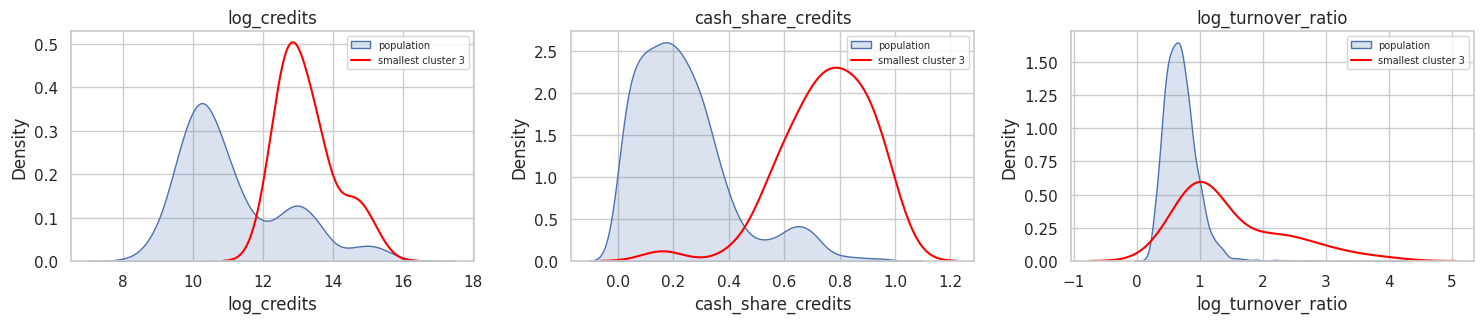

In [19]:
km = KMeans(6, n_init=10, random_state=0).fit(Z); lab = km.labels_
print(f"SSE = {km.inertia_:,.0f} | silhouette = {silhouette_score(Z, lab, sample_size=2000, random_state=0):.3f} | Davies-Bouldin (lower better) = {davies_bouldin_score(Z, lab):.3f} | Calinski-Harabasz = {calinski_harabasz_score(Z, lab):,.0f}")
prof = feat.assign(cluster=lab).groupby("cluster").agg(size=("customer_id", "size"), median_credits=("monthly_credits", "median"), cash_share=("cash_share_credits", "mean"), near_ctr=("near_ctr_cnt", "mean"), suspicious_rate=("is_launderer", "mean"))
display(prof.sort_values("size"))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4)); small = prof["size"].idxmin()
for a_, v_ in zip(ax, ["log_credits", "cash_share_credits", "log_turnover_ratio"]):
    sns.kdeplot(feat[v_], ax=a_, label="population", fill=True, alpha=.2); sns.kdeplot(feat.loc[lab == small, v_], ax=a_, label=f"smallest cluster {small}", color="red"); a_.set_title(v_); a_.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [20]:
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40, random_state=0).fit(feat[CL], lab)
print("tree explains cluster membership with accuracy", round(tree.score(feat[CL], lab), 3)); print(export_text(tree, feature_names=CL, max_depth=3)[:1500])
new = feat[CL].iloc[[0]]; print("assigning a new observation to a cluster with the tree:", int(tree.predict(new)[0]), "| with k-means:", int(km.predict(StandardScaler().fit(feat[CL]).transform(new))[0]))
grade("k-means distance to centroid", np.linalg.norm(Z - km.cluster_centers_[lab], axis=1)); grade("small-cluster membership (1/size)", 1 / pd.Series(lab).map(pd.Series(lab).value_counts()).values)

tree explains cluster membership with accuracy 0.859
|--- flowthrough_max <= 0.38
|   |--- night_share <= 0.07
|   |   |--- log_amt_cash_deposit <= 8.56
|   |   |   |--- class: 0
|   |   |--- log_amt_cash_deposit >  8.56
|   |   |   |--- class: 2
|   |--- night_share >  0.07
|   |   |--- log_credits <= 10.67
|   |   |   |--- class: 4
|   |   |--- log_credits >  10.67
|   |   |   |--- class: 2
|--- flowthrough_max >  0.38
|   |--- cash_share_credits <= 0.10
|   |   |--- log_mean_amt <= 8.60
|   |   |   |--- class: 5
|   |   |--- log_mean_amt >  8.60
|   |   |   |--- class: 5
|   |--- cash_share_credits >  0.10
|   |   |--- log_amt_cash_deposit <= 10.60
|   |   |   |--- class: 2
|   |   |--- log_amt_cash_deposit >  10.60
|   |   |   |--- class: 1

assigning a new observation to a cluster with the tree: 1 | with k-means: 1


{'AUC': 0.8444210115776016, 'P@100': np.float64(0.46)}

## 13 · One-class SVMs
Separate the bulk of observations from the **origin** in feature space with a hyperplane **wᵀφ(x) − ρ = 0**; points on the origin's side are **outliers**. Optimisation: minimise ½Σwᵢ² − ρ + (1/νn) Σ eₖ  subject to wᵀφ(xₖ) ≥ ρ − eₖ, eₖ ≥ 0. **ν ∈ (0,1) is an upper bound on the fraction of outliers** (and a lower bound on the fraction of support vectors). A kernel φ (e.g. RBF) allows non-linear "normal" regions.

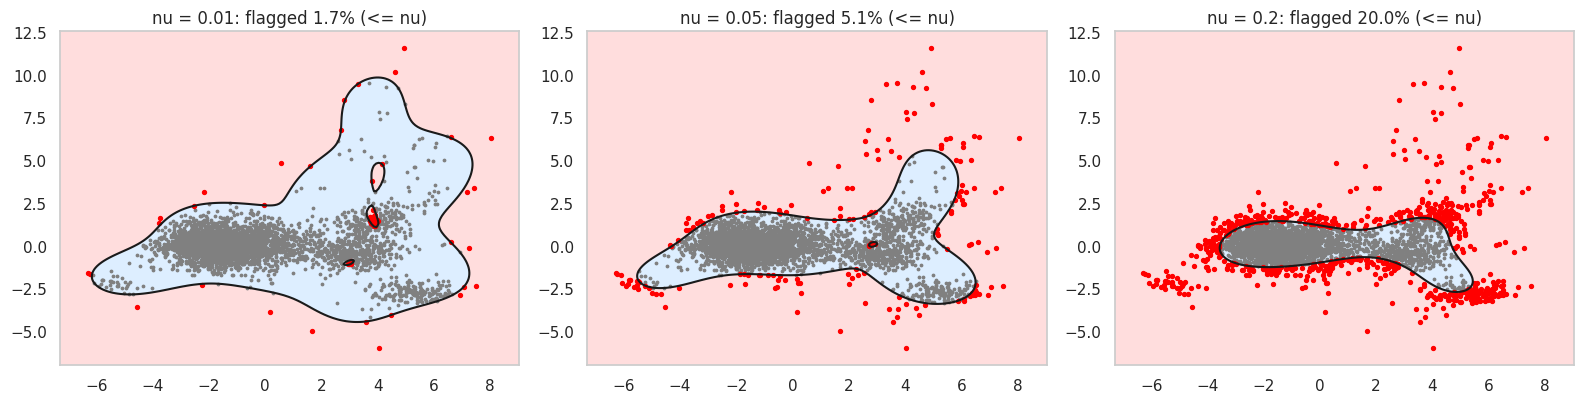

,flagged,AUC,suspicious_rate_of_flagged
"nu=0.02, gamma=scale",0.0226,0.8648,0.4177
"nu=0.02, gamma=0.01",0.0194,0.8016,0.5294
"nu=0.05, gamma=scale",0.0506,0.8692,0.3729
"nu=0.05, gamma=0.01",0.0503,0.8234,0.3523
"nu=0.1, gamma=scale",0.0994,0.8746,0.2328
"nu=0.1, gamma=0.01",0.1000,0.8326,0.2029


{'AUC': 0.9065173062154075, 'P@100': np.float64(0.45)}

In [21]:
Pz = PCA(2).fit_transform(Z); fig, ax = plt.subplots(1, 3, figsize=(16, 4.2)); gx, gy = np.meshgrid(np.linspace(Pz[:, 0].min() - 1, Pz[:, 0].max() + 1, 200), np.linspace(Pz[:, 1].min() - 1, Pz[:, 1].max() + 1, 200))
for a_, nu in zip(ax, [0.01, 0.05, 0.2]):
    oc = OneClassSVM(nu=nu, kernel="rbf", gamma="scale").fit(Pz); dfun = oc.decision_function(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape); flagged = oc.predict(Pz) == -1
    a_.contourf(gx, gy, dfun, levels=[dfun.min(), 0, dfun.max()], colors=["#ffdddd", "#ddeeff"]); a_.contour(gx, gy, dfun, levels=[0], colors="k"); a_.scatter(*Pz[~flagged].T, s=3, c="grey"); a_.scatter(*Pz[flagged].T, s=8, c="red")
    a_.set_title(f"nu = {nu}: flagged {flagged.mean():.1%} (<= nu)")
plt.tight_layout(); plt.show()
rows = {}
for nu in (0.02, 0.05, 0.1):
    for g_ in ("scale", 0.01):
        oc = OneClassSVM(nu=nu, kernel="rbf", gamma=g_).fit(Z); s_ = -oc.decision_function(Z); rows[f"nu={nu}, gamma={g_}"] = dict(flagged=(oc.predict(Z) == -1).mean(), AUC=roc_auc_score(y, s_), suspicious_rate_of_flagged=y[oc.predict(Z) == -1].mean())
display(pd.DataFrame(rows).T)
grade("One-class SVM (nu=0.05)", -OneClassSVM(nu=0.05, gamma="scale").fit(Z).decision_function(Z)); grade("Isolation forest", -IsolationForest(n_estimators=300, random_state=0).fit(Z).score_samples(Z))

## 14 · Comparison of the descriptive methods on the lab data (graded with the oracle)

In [22]:
res = pd.DataFrame(RESULTS).T.sort_values("AUC", ascending=False); print(f"base rate {y.mean():.3f}"); res.style.format("{:.3f}").background_gradient(cmap="Greens")

base rate 0.035


,AUC,P@100
Isolation forest,0.907,0.450
SOM quantization error,0.874,0.570
One-class SVM (nu=0.05),0.869,0.520
Gaussian-mixture density,0.848,0.290
small-cluster membership (1/size),0.844,0.460
z-score (max over 3 vars),0.830,0.320
Mahalanobis distance,0.818,0.310
k-means distance to centroid,0.818,0.400
"Break-point (max t, cash weeks)",0.738,0.130
Peer-group t (cash weeks),0.481,0.180


### Chapter 3 take-aways
* Different techniques answer **different questions**: global outliers (z, Mahalanobis, one-class SVM), **change** (break-point), **deviation from similar accounts** (peer group), **co-occurrence/rings** (association rules), **segments & sparse anomalies** (clustering/SOM).
* Break-point catches *sudden* change; peer-group catches *persistent* deviation **and** is immune to universal seasonality.
* Standardize before any distance-based method; choose Jaccard over SMC for sparse red flags; check **stability across seeds**; interpret clusters with profiles and trees.
* Constraints let scarce expert knowledge steer clustering; ν in one-class SVM is your **alert-volume knob**.

**Next → `03c_ch4_predictive_analytics_concepts`**